## Isolate discrete drought and insect-induced mortality events from LCMS

In [1]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import os
from scipy import ndimage, spatial
import dask
import shapely
import geopandas as gpd
from itertools import compress

In [2]:
lcms = xr.open_zarr(
    "s3://nasa-cryo-persistent/ganzk/lcms/lcms.zarr/"
).assign_coords(band=["dim_change", "fire_change", "loss_fraction"])

In [3]:
lcms

<xarray.Dataset> Size: 51GB
Dimensions:      (time: 39, band: 3, y: 7590, x: 7120)
Coordinates:
  * time         (time) int64 312B 1986 1987 1988 1989 ... 2021 2022 2023 2024
  * band         (band) <U13 156B 'dim_change' 'fire_change' 'loss_fraction'
  * y            (y) float64 61kB 3.217e+06 3.217e+06 ... 9.41e+05 9.406e+05
  * x            (x) float64 57kB -2.697e+06 -2.697e+06 ... -5.614e+05
Data variables:
    band_data    (time, band, y, x) float64 51GB dask.array<chunksize=(39, 3, 512, 512), meta=np.ndarray>
    spatial_ref  int64 8B ...

#### Change detection

LCMS frequently has salt-and-pepper noise from slight interannual changes in land cover probability. We isolate mortality events from the LCMS signal by
 - detecting significant changes with X-bar charts
 - masking mortality with antecedent wildfire, since fire was likely the inciting incident

In [4]:
from typing import Optional

def make_transformation_matrix(D: int, lam: float=0.5) -> np.array:
    '''
    Make transformation matrix for EWMA. This function returns
    a matrix that can be matrix multiplied with a time series of size
    D to get an exponentially weighted moving average.
    
    https://web.stanford.edu/~boyd/papers/pdf/ewmm.pdf

    D: size of resulting square matrix (= size of time series to be EWMA'd)
    lam: forget factor in (0, 1] controlling rate of decay. lam == 1 implies
    no decay, lam near zero implies rapid decay.
    '''
    dd = np.arange(D)
    
    # Normalization factor per row
    ai = (1 - lam) / (1 - np.power(lam, dd+1))
    
    ii, jj = np.meshgrid(dd, dd)
    L = np.power(lam, ii-jj) * ai
    L[jj > ii] = 0
    return L

def ewma_change_detection(
    arr: np.array, transform_matrix: np.array,
    lam: float=0.5, train_end: int=15, change_threshold: float=3.0,
    signal_threshold: float=0.1, run_size: int=4
):
    '''
    Return index of first change detection, based on:
    https://doi.org/10.1109/TGRS.2013.2272545

    arr: (N,) array of values for change detection
    transform_matrix: (N-train_end, N-train_end) EWMA transformation matrix
    lam(bda): decay factor giving weight to historical values
    train_end: index of end of training period in arr
    change_threshold: number of standard deviations from which EWMA signal
        must deviate to result in a change event.
    '''
    # Transform signal and separate historical/test period
    if transform_matrix is None:
        transform_matrix = make_transformation_matrix(arr.shape[0], lam)
    
    arr_ewma = arr @ transform_matrix

    # Statistics from historical period
    mu = np.mean(arr_ewma[:train_end])
    var = np.var(arr_ewma[:train_end])
    
    # Calculate upper CL only because we only care about 
    # excess mortality signals
    cl_factor = np.sqrt((lam / (2 - lam)))
    cl = mu + var * change_threshold * cl_factor
    signals = (arr_ewma > cl) & (arr_ewma > signal_threshold)
    signals[:train_end] = 0

    # Identify runs of desired length
    # operator = np.ones(run_size)
    # left_aligned_convolve = np.convolve(signals, operator)[run_size-1:]
    # has_run = left_aligned_convolve == run_size

    # Shift detections to align with original array
    # signal_idx = np.where(signals)[0]+train.shape[0]
    # run_idx = np.where(has_run)[0]+train.shape

    return signals

def threshold_change_detection(
    arr: np.array, signal_threshold: float=10
):
    '''
    Identify which pixels in `arr` exceed a threshold.
    '''
    return arr > signal_threshold

Identify a test location as a location with high variance.

In [5]:
signal_variance = lcms.var(dim="time").compute()

/srv/conda/envs/notebook/lib/python3.12/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


In [6]:
signal_variance

<xarray.Dataset> Size: 1GB
Dimensions:      (band: 3, y: 7590, x: 7120)
Coordinates:
  * band         (band) <U13 156B 'dim_change' 'fire_change' 'loss_fraction'
  * y            (y) float64 61kB 3.217e+06 3.217e+06 ... 9.41e+05 9.406e+05
  * x            (x) float64 57kB -2.697e+06 -2.697e+06 ... -5.614e+05
Data variables:
    band_data    (band, y, x) float64 1GB nan nan nan nan ... nan nan nan nan
    spatial_ref  float64 8B 0.0

(array([1.1672079e+07, 5.5900000e+02, 1.2700000e+02, 3.6000000e+01,
        1.7000000e+01, 1.7000000e+01, 9.0000000e+00, 8.0000000e+00,
        5.0000000e+00, 3.0000000e+00]),
 array([  0.        ,  19.56434958,  39.12869917,  58.69304875,
         78.25739834,  97.82174792, 117.3860975 , 136.95044709,
        156.51479667, 176.07914626, 195.64349584]),
 <BarContainer object of 10 artists>)

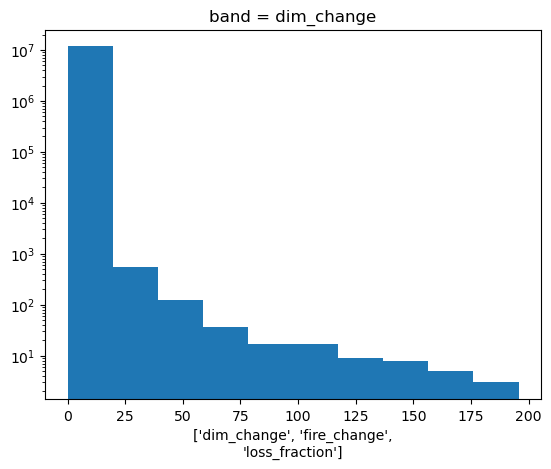

In [7]:
signal_variance.band_data.sel(band="dim_change").plot.hist(yscale="log")

In [8]:
high_var_y, high_var_x = np.where(signal_variance.band_data.sel(band="dim_change") > 25)

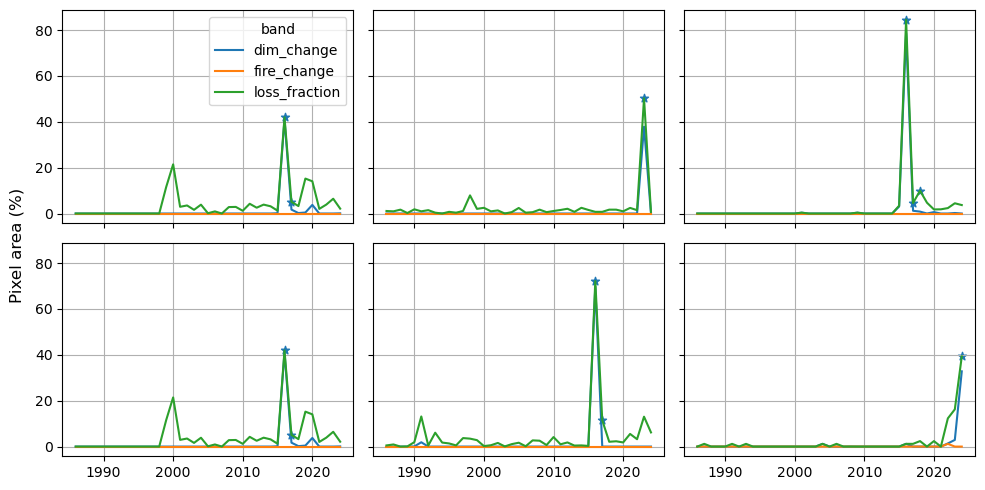

In [9]:
n_samples = 6
sample_idxs = np.random.choice(high_var_x.shape[0], size=n_samples)
transform_matrix = make_transformation_matrix(lcms.sizes["time"], lam=0.5)
train_end = 15

fig, axes = plt.subplots(2, n_samples // 2, sharex=True, sharey=True, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    test_x, test_y = high_var_x[sample_idxs[i]], high_var_y[sample_idxs[i]]
    
    orig_signal = lcms.band_data.isel(x=test_x, y=test_y).compute()
    signals = ewma_change_detection(orig_signal.sel(band="dim_change").data, transform_matrix=transform_matrix, lam=0.5, signal_threshold=10, train_end=train_end)

    signals = np.where(signals)[0]
    
    orig_signal.plot.line(x="time", hue="band", ax=ax, add_legend=i == 0)
    #ax.plot(ewma_arr, label="ewma transform")
    ax.scatter(orig_signal.time[signals], orig_signal.sel(band="loss_fraction").data[signals], marker="*", label="control signals")
    #ax.scatter(runs, ewma_arr[runs]-0.01, marker="*", label="runs")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    ax.grid()

fig.supylabel("Pixel area (%)")
plt.tight_layout()
plt.show()

#### Vectorize and apply over all pixels

We want to identify mortality, non-mortality pixels, and mask out fire-related events in one shot. The below functions achieve this, and we combine them all together in a driver function that we use to dispatch dask jobs.

In [14]:
def label_ewma_detections(
    ds: xr.Dataset, lam: float, transform_matrix: np.array, 
    signal_threshold: float=10,  **kwargs
) -> list[dict]:
    # Find positive detections
    dim_array = ds.band_data.sel(band="dim_change").fillna(0).transpose("y", "x", "time")
    
    detections = xr.apply_ufunc(
        ewma_change_detection,
        dim_array,
        kwargs=dict(lam=lam, transform_matrix=transform_matrix, signal_threshold=signal_threshold, **kwargs),
        input_core_dims=[["time"]],
        output_core_dims=[["time_shift"]],
        output_dtypes=[int],
        vectorize=True,
    )

    # Label positive detections
    struct = np.ones((3, 3, 3))

    object_labels, n_feats = ndimage.label(detections, structure=struct)
    objects = ndimage.find_objects(object_labels)
    object_dim_severity = ndimage.mean(dim_array, object_labels, index=list(range(n_feats)))

    # Recreate selectors using the *coordinates* in this array
    objects_coords = [
        dict(
            y = ds.y.isel(y=o[0]).data,
            x = ds.x.isel(x=o[1]).data,
            time = ds.time.isel(time=o[2]).data 
        ) 
        for o in objects
    ]

    return objects_coords, object_dim_severity

def label_nondetections(ds: xr.Dataset, signal_threshold: float=10) -> tuple[np.ndarray, np.ndarray]:
    # Find negative detections - stable pixels that are never nan and never
    # exceed the threshold.
    non_detect_yi, non_detect_xi = np.where(
        (ds.band_data.sel(band="loss_fraction") < signal_threshold).all(dim="time") &
        ((~ds.band_data.sel(band="loss_fraction").isnull()).all(dim="time"))
    )

    # Convert non-detect *indices* to non-detect *coordinates*
    non_detect_y = ds.y.data[non_detect_yi]
    non_detect_x = ds.x.data[non_detect_xi]

    return non_detect_y, non_detect_x

def fire_filter(ds: xr.Dataset, detection: dict, fire_mask_window: int=5, signal_threshold: float=10) -> bool:
    # Check if fire-induced change exceeds the signal threshold prior to the detection.
    selector = dict(
        x=detection["x"],
        y=detection["y"],
        time=slice(detection["time"][0]-fire_mask_window, detection["time"][0])
    )

    mean_fire_loss = ds.band_data.sel(band="fire_change", x=selector["x"], y=selector["y"], time=selector["time"]).mean(dim=["x", "y"])
    return (mean_fire_loss < signal_threshold).all(dim="time")

In [11]:
test_ds = lcms.isel(x=slice(2048, 2560), y=slice(2048, 2560))

In [21]:
def ewma_label_dask_driver(ds: xr.Dataset, transform_matrix: np.ndarray, lam: float=0.5, signal_threshold: float=10, fire_mask_window: int=5):
    ds = ds.compute()
    non_detect_y, non_detect_x = label_nondetections(ds, signal_threshold)
    detections, severity = label_ewma_detections(ds, lam, transform_matrix, signal_threshold=signal_threshold)
    no_fire = np.array([fire_filter(ds, x, fire_mask_window, signal_threshold) for x in detections])
    detections_filtered = list(compress(detections, no_fire))
    severity_filtered   = list(compress(severity, no_fire))
    return detections_filtered, severity_filtered, non_detect_y, non_detect_x

In [22]:
test_ds = lcms.isel(x=slice(2048, 3072), y=slice(2048, 3072))

objects, severity, non_detect_y, non_detect_x = ewma_label_dask_driver(test_ds, lam=0.5, transform_matrix=transform_matrix, signal_threshold=10)

In [23]:
def plot_detection(obj, ax=None, **kwargs):
    if ax is None:
        _, ax = plt.subplots()

    lcms_sel = lcms.band_data.sel(x=obj["x"], y=obj["y"]).mean(dim=["x", "y"])
    lcms_sel.plot(x="time", hue="band", ax=ax, **kwargs)
    ax.scatter(obj['time'], lcms_sel.sel(band="dim_change", time=obj["time"]).data, marker="*")
    return ax

<Axes: xlabel='time', ylabel="['dim_change', 'fire_change',\n'loss_fraction']">

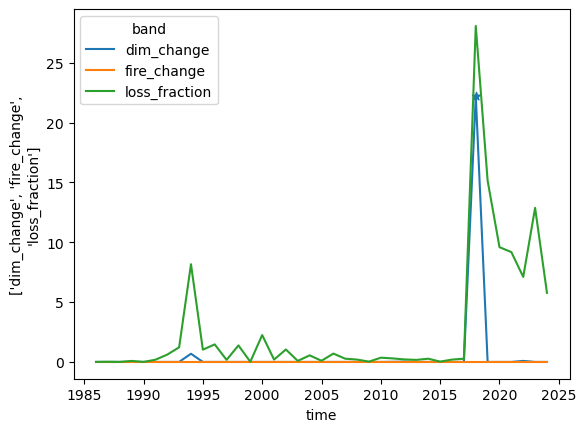

In [24]:
plot_detection(objects[4])

In [ ]:
from dask.distributed import LocalCluster

cluster = LocalCluster(n_workers=4)
client = cluster.get_client()
client

In [28]:
# Make delayed objects of all the chunks to be labeled
y_chunks = list(lcms.chunks["y"])
x_chunks = list(lcms.chunks["x"])
chunk_edges_y = np.cumsum([0] + y_chunks)
chunk_edges_x = np.cumsum([0] + x_chunks)

lam=0.5
transform_matrix = make_transformation_matrix(lcms.sizes["time"], lam=lam)
signal_threshold = 5
fire_mask_window = 5

futures = []
for iy in range(len(chunk_edges_y)-1):
    for ix in range(len(chunk_edges_x)-1):
        this_selector = dict(
            y=slice(chunk_edges_y[iy], chunk_edges_y[iy+1]),
            x=slice(chunk_edges_x[ix], chunk_edges_x[ix+1])
        )

        lcms_sel = lcms.isel(**this_selector)

        futures.append(
            client.submit(
                ewma_label_dask_driver, 
                lcms_sel,
                transform_matrix,
                lam,
                signal_threshold,
                fire_mask_window
            )
        )

In [29]:
results = client.gather(futures)

In [30]:
# Collect all the detections together. There's only a few thousand so this does not 
# need to be super efficient.
all_detections = []
for r in results: all_detections.extend(r[0])
print(len(all_detections))

6503


In [35]:
# Collect all the non-detections together.
severity = np.concatenate(
    [r[1] for r in results]
)

non_detect_y = np.concatenate(
    [r[2] for r in results]
)
non_detect_x = np.concatenate(
    [r[3] for r in results]
)

(array([7.400e+01, 2.000e+00, 1.058e+03, 2.810e+03, 1.765e+03, 5.830e+02,
        1.530e+02, 4.600e+01, 9.000e+00, 3.000e+00]),
 array([1.15412393e-04, 2.40000621e+00, 4.79989702e+00, 7.19978782e+00,
        9.59967862e+00, 1.19995694e+01, 1.43994602e+01, 1.67993510e+01,
        1.91992418e+01, 2.15991326e+01, 2.39990234e+01]),
 <BarContainer object of 10 artists>)

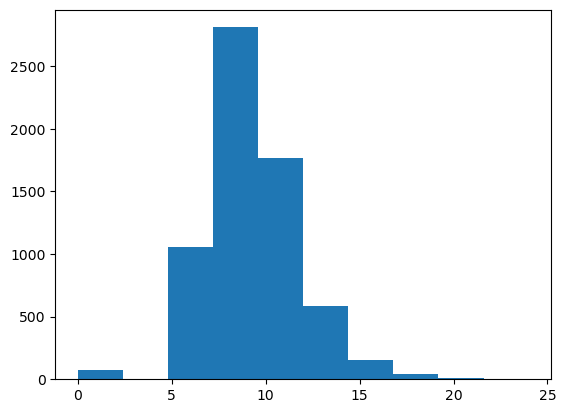

In [36]:
# Visualize the severity distribution
plt.hist(severity)

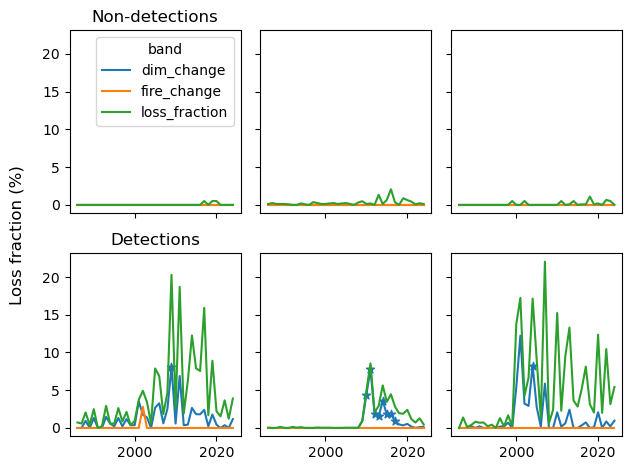

In [32]:
# Visualize a couple of each
n_signals = 3
non_detection_sample = np.random.choice(non_detect_y.shape[0], n_signals)
detection_sample = np.random.choice(len(all_detections), n_signals)

fig, axes = plt.subplots(2, n_signals, sharex=True, sharey=True)

# Non detections
for i in range(n_signals):
    this_non_detect_x = non_detect_x[non_detection_sample[i]]
    this_non_detect_y = non_detect_y[non_detection_sample[i]]
    signal = lcms.band_data.sel(x=this_non_detect_x, y=this_non_detect_y).compute()
    signal.plot(hue="band", x="time", ax=axes[0, i], add_legend=(i==0))

    axes[0, i].set_xlabel("")
    axes[0, i].set_ylabel("")
    axes[0, i].set_title("")

# Detections
for i in range(n_signals):
    this_detection = all_detections[detection_sample[i]]
    plot_detection(this_detection, ax=axes[1, i], add_legend=False)
    axes[1, i].set_ylabel("")
    axes[1, i].set_xlabel("")

axes[0, 0].set_title("Non-detections")
axes[1, 0].set_title("Detections")

fig.supylabel("Loss fraction (%)")
plt.tight_layout()
plt.show()

In [33]:
cluster.close()

#### Are overlaps a problem?

If a mortality event spans the edge of a processing tile, we might be splitting it in half. Convert the bounding boxes to shapely geometries and check for touching edges in the same year.

In [37]:
def detection_to_bbox(d: dict, pixel_size: float=300):
    # Y coordinate is decreasing
    return shapely.geometry.box(
        d["x"][0],
        d["y"][-1]-pixel_size,
        d["x"][-1]+pixel_size,
        d["y"][0]
    )

In [38]:
for test_year in range(2000, 2025):
    detections_filter = list(filter(lambda x: test_year in x["time"], all_detections))
    detections_bbox   = list(map(detection_to_bbox, detections_filter))
    detections_orient = list(map(shapely.geometry.polygon.orient, detections_bbox))

    if len(detections_bbox) == 0:
        continue

    assert(all(map(shapely.is_valid, detections_bbox)))

    try:
        detections_union = shapely.coverage_union_all(detections_orient)
        n_overlaps = len(detections_orient) - len(detections_union.geoms)
    except shapely.GEOSException as e:
        # Underlying issue in GEOS: https://github.com/libgeos/geos/issues/1355
        print(f"{test_year} failed: {e}")
        continue

    if n_overlaps > 0:
        print(f"{test_year}: {n_overlaps}")

2003 failed: AssertionFailedException: found two shells in EdgeRing list
2004 failed: AssertionFailedException: found two shells in EdgeRing list
2005 failed: AssertionFailedException: found two shells in EdgeRing list
2012 failed: AssertionFailedException: found two shells in EdgeRing list
2013 failed: AssertionFailedException: found two shells in EdgeRing list
2014: 1
2015: 1
2019 failed: AssertionFailedException: found two shells in EdgeRing list


Of several thousand detections, there are only two overlaps. So, we can go ahead and ignore those. Let's plot the distribution of detection events.

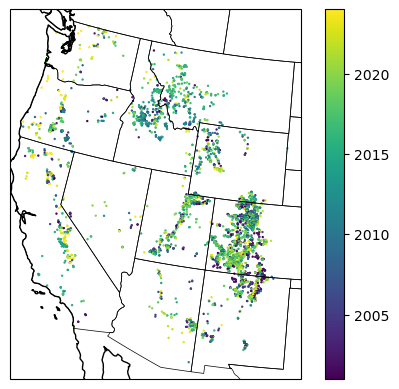

In [39]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

detection_x_mean = list(map(lambda d: d["x"].mean(), all_detections))
detection_y_mean = list(map(lambda d: d["y"].mean(), all_detections))
detection_start  = list(map(lambda d: d["time"][0], all_detections))

projection = ccrs.AlbersEqualArea(
    central_longitude=-96,
    central_latitude=23,
    standard_parallels=(29.5, 45.5)
)

fig, ax = plt.subplots(subplot_kw=dict(projection=projection))

s = ax.scatter(detection_x_mean, detection_y_mean, c=detection_start, cmap=plt.get_cmap("viridis"), s=0.5)

ax.coastlines()
ax.add_feature(cfeature.STATES, linewidth=0.5)
fig.colorbar(s)
plt.show()

Find non-detections that are closest to the detections, but separated by at least a pixel (= 600 m)

In [40]:
non_detection_kdtree = spatial.KDTree(np.stack([non_detect_x, non_detect_y], axis=-1))

In [41]:
distances, non_detection_neighbors = non_detection_kdtree.query(
    np.stack([detection_x_mean, detection_y_mean], axis=-1),
    k=5
)

non_detection_neighbors[distances < 600] = -1

In [42]:
# Subset to unique non-detections
non_detection_neighbors_unique = np.unique(non_detection_neighbors)[1:] # drop leading -1

# Get the coordinates for those non-detections
non_detect_subset_x = non_detect_x[non_detection_neighbors_unique]
non_detect_subset_y = non_detect_y[non_detection_neighbors_unique]

# Randomly sample an equal number of non-detections
non_detect_sample = np.random.choice(non_detect_subset_x.shape[0], size=len(all_detections))
non_detect_sample_x = non_detect_subset_x[non_detect_sample]
non_detect_sample_y = non_detect_subset_y[non_detect_sample]

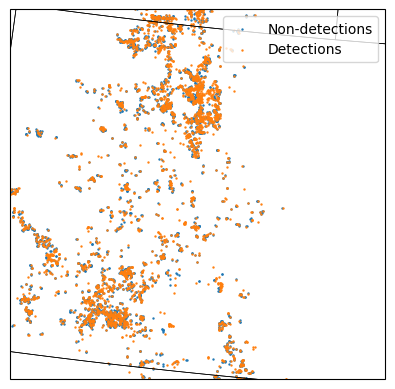

In [43]:
fig, ax = plt.subplots(subplot_kw=dict(projection=projection))

ax.scatter(non_detect_sample_x, non_detect_sample_y, label="Non-detections", s=0.5)
ax.scatter(detection_x_mean, detection_y_mean, label="Detections", s=0.5)

ax.coastlines()
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.legend()

# zoom in to Colorado
ax.set_xlim(-1093890.211278, -606573.904315)
ax.set_ylim(1586816.935535, 2066898.884974)

plt.show()

Package up points and save.

In [42]:
detection_geoms = list(map(detection_to_bbox, all_detections))

detection_tmin = [d["time"][0] for d in all_detections]
detection_tmax = [d["time"][-1] for d in all_detections]

nondetection_geoms = [
    shapely.geometry.box(
        x,
        y-300,
        x+300,
        y
    )
    for (x, y) in zip(non_detect_sample_x, non_detect_sample_y)
]

In [43]:
output_gdf = gpd.GeoDataFrame(
    data=dict(
        tmin = detection_tmin + [-1] * len(nondetection_geoms),
        tmax = detection_tmax + [-1] * len(nondetection_geoms),
        severity = severity.tolist() + [0] * len(nondetection_geoms)
    ),
    geometry=gpd.GeoSeries(detection_geoms + nondetection_geoms, crs="EPSG:5071")
)
output_gdf

,tmin,tmax,geometry
0,2024,2024,"POLYGON ((-2064150 3092550, -2064150 3092850, ..."
1,2021,2021,"POLYGON ((-1864350 3134550, -1864350 3134850, ..."
2,2015,2015,"POLYGON ((-1802550 3121350, -1802550 3121650, ..."
3,2018,2018,"POLYGON ((-1802550 3115950, -1802550 3116250, ..."
4,2021,2021,"POLYGON ((-1802550 3115650, -1802550 3116250, ..."
...,...,...,...
13001,-1,-1,"POLYGON ((-955350 1679550, -955350 1679850, -9..."
13002,-1,-1,"POLYGON ((-970650 1954950, -970650 1955250, -9..."
13003,-1,-1,"POLYGON ((-1197150 2759550, -1197150 2759850, ..."
13004,-1,-1,"POLYGON ((-1270950 2039850, -1270950 2040150, ..."


In [45]:
output_gdf.to_parquet("../data_working/detections.parquet")